# Balanced Binary Search Trees

### Chris Tralie

In [1]:
import numpy as np
import matplotlib.pyplot as plt

UNDEFINED = -2

class TreeNode(object):
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None
        self.x = 0
        self.h = UNDEFINED

    def compute_height(self):
        if self.h == UNDEFINED:
            max_h = -1
            if self.left:
                max_h = self.left.compute_height()
            if self.right:
                max_h = max(max_h, self.right.compute_height())
            self.h = max_h + 1
        return self.h

    def inorder(self, arr):
        """
        arr: list
            The list I will fill with all elements
            in the tree inorder. I'm sharing it by reference
            between all recursive calls
        """
        if self.left:
            self.left.inorder(arr)
        self.x = len(arr)
        arr.append(self.value)
        if self.right:
            self.right.inorder(arr)
    
    def draw(self, x, y, opts):
        """
        Options:
            Variable dictionary of drawing options

            * draw_vert: If this is specified, draw vertical lines
            * inorder_x: If this is specified, then I'll use inorder x
        """
        if "inorder_x" in opts:
            x = self.x
        plt.text(x, y, f"{self.value}({self.h})")
        plt.scatter(x, y, 5)
        if "draw_vert" in opts:
            plt.axvline(x, linestyle='--', c='k')
        depth = 1-y 
        dx = 1/(2**depth)
        if self.left:
            x2 = x - dx
            if "inorder_x" in opts:
                x2 = self.left.x
            y2 = y-1
            plt.plot([x, x2], [y, y2])
            self.left.draw(x2, y2, opts)
        if self.right:
            x2 = x + dx
            if "inorder_x" in opts:
                x2 = self.right.x
            y2 = y-1
            plt.plot([x, x2], [y, y2])
            self.right.draw(x2, y2, opts)

    def add(self, val):
        current_val = self.value
        if val < current_val:
            if self.left:
                self.left.add(val)
            else:
                self.left = TreeNode(val)
        if val > current_val:
            if self.right:
                self.right.add(val)
            else:
                self.right = TreeNode(val) 

    def contains(self, val):
        ret = False
        current_val = self.value
        if val == current_val:
            ret = True
        elif val < current_val:
            if self.left:
                ret = self.left.add(val)
        elif val > current_val:
            if self.right:
                self.right.add(val)
        return ret
        
        

class BinaryTree(object):
    def __init__(self):
        self.root = None
    
    def draw(self, opts={}):
        if self.root:
            self.root.inorder([])
            self.root.draw(0, 0, opts)

    def inorder(self):
        arr = []
        if self.root:
            self.root.inorder(arr)
        return arr

    def add(self, value):
        if self.root: # Is this not None?
            self.root.add(value)
        else:
            self.root = TreeNode(value)
            
    def compute_heights(self):
        if self.root:
            self.root.compute_height()
    
    def __contains__(self, value):
        ret = False
        if self.root:
            ret = self.root.contains(value)
        return ret

### Unbalanced Binary Search Tree

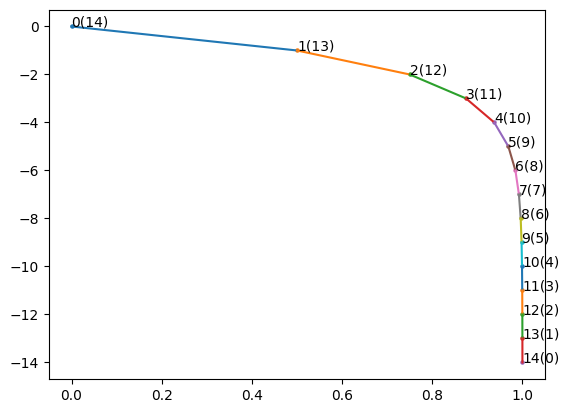

In [2]:
T = BinaryTree()
for x in range(15):
    T.add(x)
T.compute_heights()
T.draw()

### Perfectly Balanced Binary Search Tree

A tree with every level full

In other words, every internal node has exactly two children


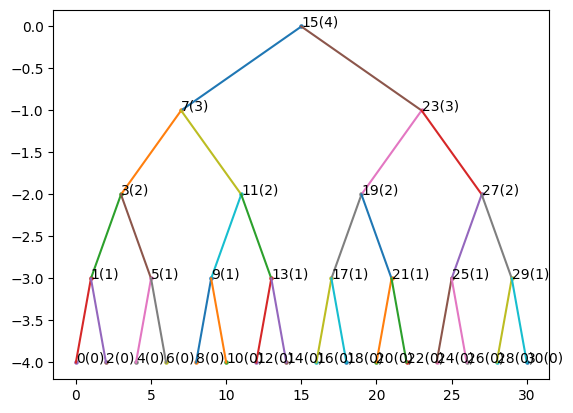

In [3]:
def add_median(T, arr):
    if len(arr) > 0:
        i = len(arr)//2
        T.add(arr[i])
        add_median(T, arr[0:i])
        add_median(T, arr[i+1:])

arr = np.arange(31)
T = BinaryTree()
add_median(T, arr)
T.compute_heights()
T.draw({"inorder_x"})

### Height of Perfectly Balanced BSTs

Def. height of a node is the length of the longest path from that node down to a leaf

Given a tree of height $h$, we have
$N_h = 1 + 2 + 4 + ... + 2^h = 2^{h+1} - 1$
for a perfectly balanced tree




If I have $N$ nodes, what would be the height of a balanced BST?

$h = \log_2(N+1) - 1$

$h$ is $O(\log(N))$, which means that add/contains/remove all take $O(\log(N)$ in a balanced BST


## AVL Trees

height(node) = max(height(node.left), height(node.right)) + 1

if node is a leaf node, height is 0
if node is None, height is -1

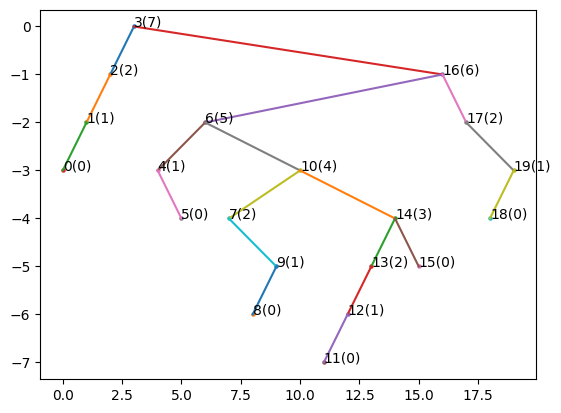

In [5]:
np.random.seed(1)
T = BinaryTree()
for x in np.random.permutation(20):
    T.add(x)
T.compute_heights()
T.draw({"inorder_x"})

Def. AVL Tree

A BST where 

|height(node.left) - height(node.right)| <= 1

Worst case AVL Trees:

<img src = "WorstCaseAVLTrees.svg">

$N_h = N_{h-1} + N_{h-2} + 1$

$N_h > 2 N_{h-2}$

$N_h > 2^{h/2}$

$h < 2 \log_2(N)$

Therefore, height $h$ is still $O(\log(N))$ in AVL tree

## Maintaining AVL Trees

<img src = "AVLBalancing.svg">